In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Cargar los datos limpios
train_df = pd.read_csv('../03_datasets/train_data_prepared.csv')
val_df = pd.read_csv('../03_datasets/val_data_prepared.csv')
test_df = pd.read_csv('../03_datasets/test_data_prepared.csv')

# ¡Eliminamos AMBOS precios de las características (X) para evitar trampas!
columnas_a_borrar = ['buy_price_log', 'rent_price']

X_train = train_df.drop(columnas_a_borrar, axis=1)
y_train = train_df['rent_price']  # <--- ¡AQUÍ ESTÁ EL GRAN CAMBIO!

X_val = val_df.drop(columnas_a_borrar, axis=1)
y_val = val_df['rent_price']      # <--- Cambio aquí también

X_test = test_df.drop(columnas_a_borrar, axis=1)
y_test = test_df['rent_price']    # <--- Y aquí

print(f"Forma de X_train: {X_train.shape}")


Forma de X_train: (11454, 16)


In [2]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

# 1. Arquitectura
model = Sequential([
    Input(shape=(X_train.shape[1],)),

    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),

    Dense(32, activation='relu'),
    Dropout(0.1),

    Dense(1)                                   # Salida lineal para regresión
])

# 2. Compilar con learning rate explícito
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mae',
    metrics=['mae']
)

# 3. Callbacks mejorados
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=8,
    min_lr=1e-6,
    verbose=1
)

# 4. Entrenar con más épocas
print("Iniciando el entrenamiento de la Red Neuronal...\n")

fit_params = {
    "validation_data": (X_val, y_val),
    "epochs": 500,
    "batch_size": 32,
    "callbacks": [early_stop, reduce_lr],
    "verbose": 1
}

history = model.fit(
    X_train, y_train,**fit_params
)


I0000 00:00:1776279634.362248   65860 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1776279634.362563   65860 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1776279634.391495   65860 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1776279635.150278   65860 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

Iniciando el entrenamiento de la Red Neuronal...

Epoch 1/500


E0000 00:00:1776279635.663314   65860 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1776279635.663567   65918 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1776279635.689422   65860 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


358/358 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 1203.0538 - mae: 1203.0538 - val_loss: 572.6667 - val_mae: 572.6667 - learning_rate: 0.0010
Epoch 2/500
358/358 ━━━━━━━━━━━━━━━━━━━━ 0s 983us/step - loss: 445.6772 - mae: 445.6772 - val_loss: 700.4340 - val_mae: 700.4340 - learning_rate: 0.0010
Epoch 3/500
358/358 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 322.5248 - mae: 322.5248 - val_loss: 408.5051 - val_mae: 408.5051 - learning_rate: 0.0010
Epoch 4/500
358/358 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 269.8985 - mae: 269.8985 - val_loss: 250.0591 - val_mae: 250.0591 - learning_rate: 0.0010
Epoch 5/500
358/358 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 251.6804 - mae: 251.6804 - val_loss: 212.4036 - val_mae: 212.4036 - learning_rate: 0.0010
Epoch 6/500
358/358 ━━━━━━━━━━━━━━━━━━━━ 0s 982us/step - loss: 247.8656 - mae: 247.8656 - val_loss: 190.4855 - val_mae: 190.4855 - learning_rate: 0.0010
Epoch 7/500
358/358 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 244.4192 - mae: 244.4192 - val_loss: 20

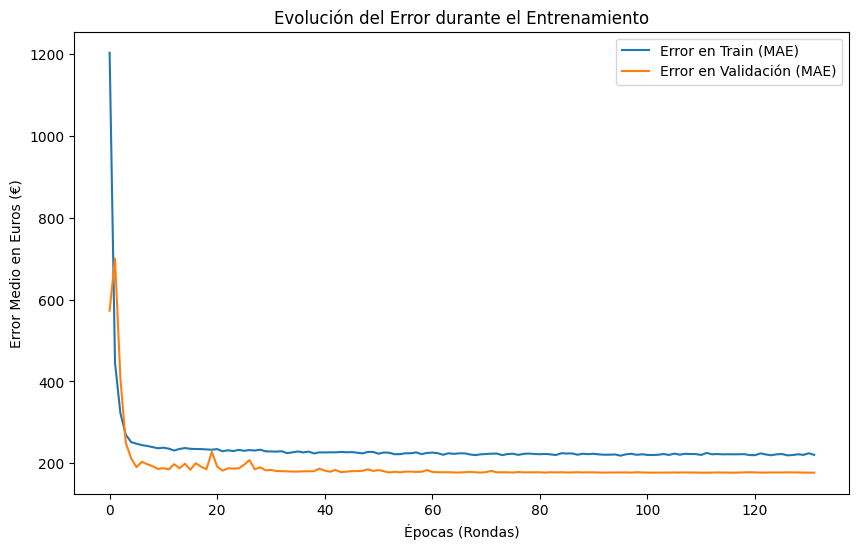

116/116 ━━━━━━━━━━━━━━━━━━━━ 0s 629us/step

--- RESULTADOS FINALES DE ALQUILER EN TEST ---
Error Absoluto Medio (MAE): 178.30 €/mes
R-Cuadrado (R2): 0.7649


In [3]:
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Ver cómo ha aprendido la red con un gráfico
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Error en Train (MAE)')
plt.plot(history.history['val_loss'], label='Error en Validación (MAE)')
plt.title('Evolución del Error durante el Entrenamiento')
plt.xlabel('Épocas (Rondas)')
plt.ylabel('Error Medio en Euros (€)')
plt.legend()
plt.show()

# 1. Hacer predicciones sobre los datos de TEST
predicciones_test = model.predict(X_test)

# 2. Calcular métricas finales (Directamente, sin conversiones)
mae = mean_absolute_error(y_test, predicciones_test)
r2 = r2_score(y_test, predicciones_test)

print("\n--- RESULTADOS FINALES DE ALQUILER EN TEST ---")
print(f"Error Absoluto Medio (MAE): {mae:,.2f} €/mes")
print(f"R-Cuadrado (R2): {r2:.4f}")

In [4]:
params = {
    "batch_size":fit_params["batch_size"],
    "epochs":fit_params["epochs"],
}

record = pd.read_csv("../models/models_log.csv")

val_r2 = r2_score(y_val, model.predict(X_val))
val_mae = mean_absolute_error(y_val, model.predict(X_val))

rent_r2 = record.loc[record["model"] == "rent_model", "r2"]
record_r2_log = 0 if rent_r2.empty or rent_r2.isna().all() else rent_r2.max()

if val_r2 > record_r2_log:
    model_type = "rent_model_DL",
    model_name = "modelo_alquiler_dl.keras",
    best_params = params,
    best_r2 = val_r2,
    best_mae = val_mae

    entry = {
        "model": "rent_model",
        "model_type": model_type,
        "model_name": model_name,
        "r2": best_r2,
        "mae": best_mae,
    }

    entry_df = pd.DataFrame(entry, index=[0])
    params_str = str(best_params)
    entry_df["params"] = params_str

    new_record = pd.concat([record, entry_df], ignore_index=True)

    new_record.to_csv("../models/models_log.csv", index=False)
    # 1. Guardar el modelo de la Red Neuronal (El "Cerebro")
    model.save('../models/modelo_alquiler_dl.keras')
    
    print(f"✅ Modelo de Red Neuronal guardado como {model_name}")
    print("\n¡Todo empaquetado y listo!")

else:
    print("No se mejoró el modelo. No se guardará.")






118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 342us/step
118/118 ━━━━━━━━━━━━━━━━━━━━ 0s 340us/step
✅ Modelo de Red Neuronal guardado como ('modelo_alquiler_dl.keras',)

¡Todo empaquetado y listo!


/tmp/ipykernel_65860/822325135.py:33: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  new_record = pd.concat([record, entry_df], ignore_index=True)
